In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
def gini(scores):
    scores = np.sort(np.array(scores))
    scores = scores[scores > 0]  
    n = len(scores)

    cumx = np.cumsum(scores)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [3]:
def lorenz_curve(scores):
    scores = np.sort(np.array(scores))
    cum_scores = np.cumsum(scores) / np.sum(scores)
    cum_people = np.arange(1, len(scores) + 1) / len(scores)
    return np.insert(cum_people, 0, 0), np.insert(cum_scores, 0, 0)

In [4]:
def plot_sorted_scores(scores, label=None, ax=None):
    scores = np.sort(np.array(scores))  # ascending: worst-served first
    ranks = np.arange(1, len(scores) + 1)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.plot(ranks, scores, marker='o', markersize=2, linewidth=1, label=label)
    #ax.axhline(np.mean(scores), color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Mean' if label is None else None)
    ax.set_xlabel('User rank (sorted by NDCG, worst to best)')
    ax.set_ylabel('NDCG score')
    ax.set_title('Sorted NDCG Scores')
    if label:
        ax.legend()
    return ax

In [ ]:
def plot_delta_by_decile(baseline_scores, intervention_scores, label="Intervention"):
    df = pd.DataFrame({
        'baseline': baseline_scores,
        'delta': np.array(intervention_scores) - np.array(baseline_scores)
    })
    df['decile'] = pd.qcut(df['baseline'], 10, labels=False, duplicates='drop')
    
    decile_means = df.groupby('decile')['delta'].mean()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['tab:green' if v >= 0 else 'tab:red' for v in decile_means]
    ax.bar(decile_means.index, decile_means.values, color=colors)
    ax.axhline(0, color='gray', linewidth=1)
    ax.set_xlabel('Baseline NDCG decile (0 = lowest scorers)')
    ax.set_ylabel('Mean \%\ change NDCG')
    ax.set_title(f'Mean NDCG change by baseline decile ({label})')
    return fig, ax

In [5]:
def analyze_fairness(files, groups = 10, provider = "female"):
    ndcg_scores = {}
    provider_fairness = {}

    for label, path in files.items():
        with open(path) as f:
            data = json.load(f)
        df = pd.json_normalize(data)
        ndcg_scores[label] = df["ndcg_scores"][0]
        provider_fairness[label] = df[f"proportional_fairness.{provider}"][0]

    baseline_scores = ndcg_scores["Baseline"]

    for label, scores in ndcg_scores.items():
        print(f"{label}: Gini = {gini(scores):.4f}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax2 = ax.twinx()

    for label, scores in ndcg_scores.items():

        delta = np.array(scores) - np.array(baseline_scores)
        percent_change = np.array(scores) / np.array(baseline_scores) * 100
        df_delta = pd.DataFrame({'baseline': baseline_scores, 'delta': delta, 'percent_change': percent_change})
        df_delta['group'] = pd.qcut(df_delta['baseline'], groups, labels=False, duplicates='drop')
        group_means = df_delta.groupby('group')['percent_change'].mean()

        # plot on primary axis, capture the color it was assigned
        line, = ax.plot(group_means.index, group_means.values, marker='o', label=label)
        color = line.get_color()

        # dotted flat line on secondary axis for provider fairness (scalar per label)
        ax2.axhline(
            provider_fairness[label],
            linestyle=':',
            color=color,
            linewidth=1.5,
            xmin=0, xmax=1,
        )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Baseline NDCG group (0 = lowest scorers)')
    ax.set_ylabel('Mean \%\ change NDCG vs baseline')
    ax2.set_ylabel(f'Provider fairness ({provider})')
    ax.set_title('NDCG change by baseline group, across interventions')

    # combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1, labels1, loc='best')

    plt.show()

In [4]:

with open("data/music/ambar_fold1_BPR_baseline.json") as f:
    data = json.load(f)

baseline = pd.json_normalize(data)

In [5]:
baseline.head()

,ndcg_scores,mean_ndcg,proportional_fairness.female
0,"[0.552265477387053, 0.08514311764162101, 0.0, ...",0.247131,0.615095


In [9]:
ndcg = baseline["ndcg_scores"][0]

In [10]:
ndcg

[0.552265477387053,
 0.08514311764162101,
 0.0,
 0.2837125544970319,
 0.5933607200949347,
 0.08514311764162101,
 0.38113435412202007,
 0.693761356516045,
 0.6352557412688554,
 0.599976751690748,
 0.2837125544970319,
 0.0,
 0.2122263659729146,
 0.22400556151517556,
 0.0,
 0.5648901044069582,
 0.35895421017163476,
 1.0,
 0.07336392209936006,
 0.0,
 0.0,
 0.0,
 0.0,
 0.13886244387355456,
 0.15840915256850252,
 0.8389574121760603,
 0.0,
 1.0,
 0.4249260138166711,
 0.20511666732794362,
 1.0,
 1.0,
 0.0,
 0.1100458831490401,
 0.0,
 0.314880130667631,
 0.26855292289002114,
 0.15840915256850252,
 0.8572048559638626,
 0.8415908474314977,
 0.0,
 0.39375843764607205,
 0.400023248309252,
 0.6830838076905166,
 0.23758350840568815,
 0.7818048722226502,
 1.0,
 0.1951890007906611,
 0.36837563413888724,
 0.06943122193677728,
 0.1100458831490401,
 0.3052348839397012,
 0.08514311764162101,
 0.0,
 0.2200917662980802,
 0.4228506620510154,
 0.6929852696575346,
 0.3909273842002217,
 0.4735717030454862,
 0.58

In [13]:
gini(ndcg)

0.6498635758170154

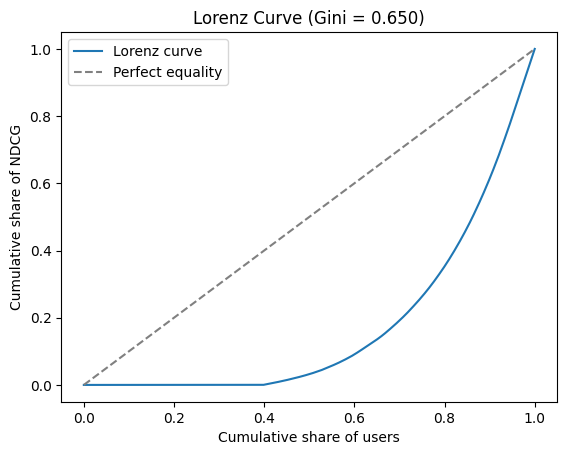

In [15]:
x, y = lorenz_curve(ndcg)
plt.plot(x, y, label='Lorenz curve')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
plt.xlabel('Cumulative share of users')
plt.ylabel('Cumulative share of NDCG')
plt.title(f'Lorenz Curve (Gini = {gini(ndcg):.3f})')
plt.legend()
plt.show()

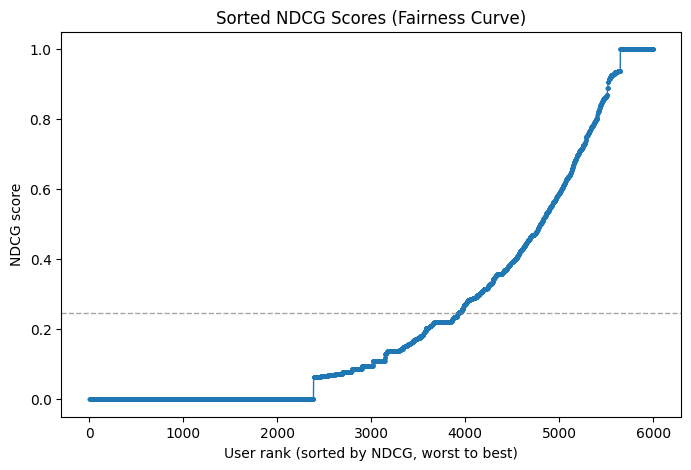

In [17]:
plot_sorted_scores(ndcg)
plt.show()

In [ ]:
ndcg_scores = {}
provider_fairness = {}
for label, path in files.items():
    with open(path) as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    ndcg_scores[label] = df["ndcg_scores"][0]
    provider_fairness[label] = df["proportional_fairness.female"][0]

baseline_scores = ndcg_scores["Baseline"]

for label, scores in ndcg_scores.items():
    print(f"{label}: Gini = {gini(scores):.4f}")

# fig, ax = plt.subplots(figsize=(8, 6))
# for label, scores in ndcg_scores.items():
#     x, y = lorenz_curve(scores)
#     ax.plot(x, y, label=f'{label} (Gini={gini(scores):.4f})')

# ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
# ax.set_xlabel('Cumulative share of users')
# ax.set_ylabel('Cumulative share of NDCG')
# ax.set_title('Lorenz Curves Comparison')
# ax.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(8, 6))
# for label, scores in ndcg_scores.items():
#     plot_sorted_scores(scores, label=label, ax=ax)
# ax.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(9, 6))
# for label, scores in ndcg_scores.items():
#     if label == "Baseline":
#         continue
#     delta = np.array(scores) - np.array(baseline_scores)
#     df = pd.DataFrame({'baseline': baseline_scores, 'delta': delta})
#     df['group'] = pd.qcut(df['baseline'], 7, labels=False, duplicates='drop')
#     group_means = df.groupby('group')['delta'].mean()
#     ax.plot(group_means.index, group_means.values, marker='o', label=label)

# ax.axhline(0, color='gray', linestyle='--', linewidth=1)
# ax.set_xlabel('Baseline NDCG group (0 = lowest scorers)')
# ax.set_ylabel('Mean Δ NDCG vs baseline')
# ax.set_title('NDCG change by baseline group, across interventions')
# ax.legend()
# plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax2 = ax.twinx()

for label, scores in ndcg_scores.items():
    if label == "Baseline":
        continue
    delta = np.array(scores) - np.array(baseline_scores)
    df = pd.DataFrame({'baseline': baseline_scores, 'delta': delta})
    df['group'] = pd.qcut(df['baseline'], 7, labels=False, duplicates='drop')
    group_means = df.groupby('group')['delta'].mean()

    # plot on primary axis, capture the color it was assigned
    line, = ax.plot(group_means.index, group_means.values, marker='o', label=label)
    color = line.get_color()

    # dotted flat line on secondary axis for provider fairness (scalar per label)
    ax2.axhline(
        provider_fairness[label],
        linestyle=':',
        color=color,
        linewidth=1.5,
        xmin=0, xmax=1,
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Baseline NDCG group (0 = lowest scorers)')
ax.set_ylabel('Mean Δ NDCG vs baseline')
ax2.set_ylabel('Provider fairness (female)')
ax.set_title('NDCG change by baseline group, across interventions')

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc='best')

plt.show()

# add agent allocation plot
# add provider side fairness plot

Baseline: Gini = 0.4189
Provider Fairness: Gini = 0.4276
Consumer Individual: Gini = 0.4179


/tmp/ipykernel_2959168/3506279871.py:23: RuntimeWarning: invalid value encountered in divide
  percent_change = np.array(scores) / np.array(baseline_scores) * 100
/tmp/ipykernel_2959168/3506279871.py:23: RuntimeWarning: divide by zero encountered in divide
  percent_change = np.array(scores) / np.array(baseline_scores) * 100
/tmp/ipykernel_2959168/3506279871.py:23: RuntimeWarning: invalid value encountered in divide
  percent_change = np.array(scores) / np.array(baseline_scores) * 100
/tmp/ipykernel_2959168/3506279871.py:23: RuntimeWarning: divide by zero encountered in divide
  percent_change = np.array(scores) / np.array(baseline_scores) * 100
/tmp/ipykernel_2959168/3506279871.py:23: RuntimeWarning: invalid value encountered in divide
  percent_change = np.array(scores) / np.array(baseline_scores) * 100


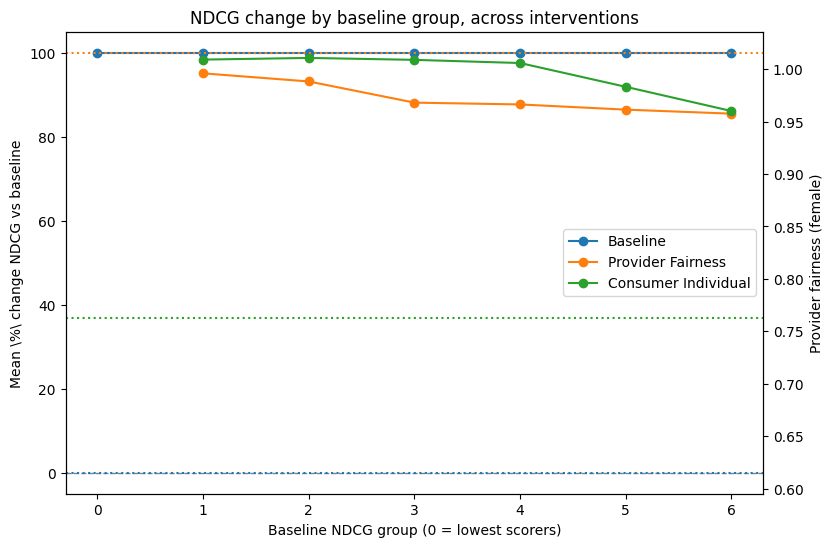

In [6]:
files = {
    "Baseline": "data/music/ambar_fold1_BPR_baseline.json",
    "Provider Fairness": "data/music/ambar_fold1_BPR_group.csv_weighted_scoring_product_lottery_0.2_fold1.json",
    "Consumer Individual": "data/music/ambar_fold1_BPR_individual.csv_weighted_scoring_product_lottery_0.08_fold1.json",
    #"LLM": "data/music/ambar_fold1_BPR_LLM.csv_weighted_scoring_product_lottery_0.2_fold1.json",
    #"LLM All": "data/music/ambar_fold1_BPR_LLMall.json",
}

analyze_fairness(files, groups=10, provider="female")


Baseline: Gini = 0.2818
Provider Lottery: Gini = 0.3335
Provider Weighted: Gini = 0.3335
Consumer Lottery: Gini = 0.3084
Consumer Weighted: Gini = 0.3124


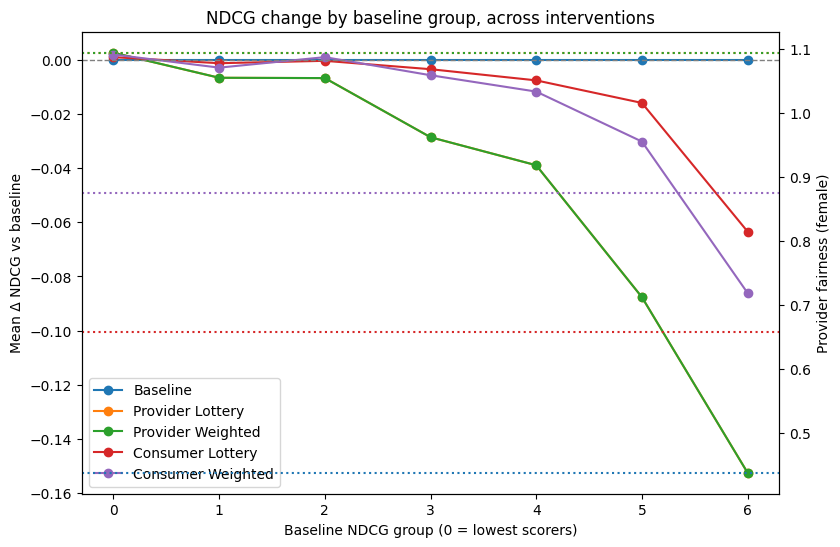

In [15]:
files = {
    "Baseline": "data/music/ambar_fold1_MultiVAE_baseline.json",
    "Provider Lottery": "data/music/ambar_fold1_MultiVAE_group.csv_weighted_scoring_product_lottery_0.2_fold1.json",
    "Provider Weighted": "data/music/ambar_fold1_MultiVAE_group.csv_weighted_scoring_weighted_product_allocation_0.2_fold1.json",
    "Consumer Lottery": "data/music/ambar_fold1_MultiVAE_individual.csv_weighted_scoring_product_lottery_0.08_fold1.json",
    "Consumer Weighted": "data/music/ambar_fold1_MultiVAE_individual.csv_weighted_scoring_weighted_product_allocation_0.08_fold1.json",
}

analyze_fairness(files, groups=20, provider="female")

Baseline: Gini = 0.3180
Provider Lottery: Gini = 0.3139
Provider Weighted: Gini = 0.3160
Consumer Lottery: Gini = 0.3139
Consumer Weighted: Gini = 0.3120


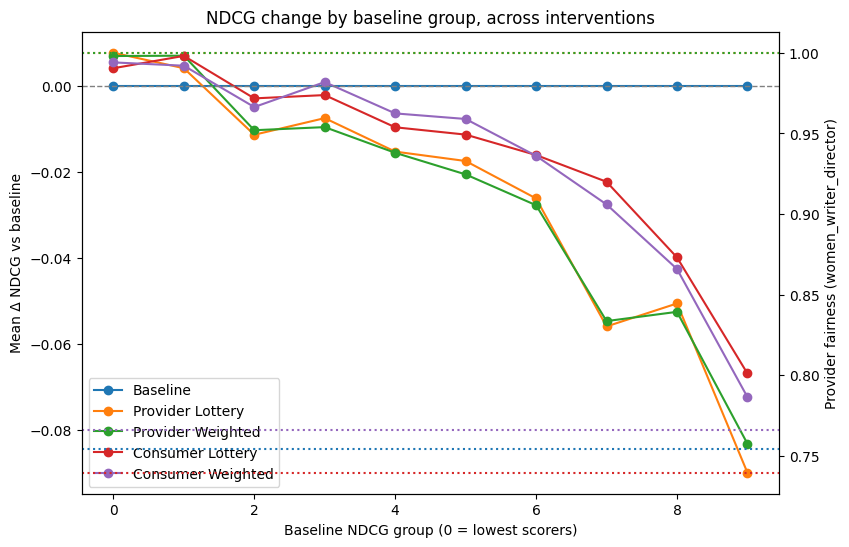

In [8]:
files = {
    "Baseline": "data/movies/movie_fold1_MultiVAE_baseline.json",
    "Provider Lottery": "data/movies/ml-1m_fold1_MultiVAE_group_weighted_scoring_product_lottery_0.1_fold1.json",
    "Provider Weighted": "data/movies/ml-1m_fold1_MultiVAE_group_weighted_scoring_weighted_product_allocation_0.1_fold1.json",
    "Consumer Lottery": "data/movies/ml-1m_fold1_MultiVAE_ind_weighted_scoring_product_lottery_0.1_fold1.json",
    "Consumer Weighted": "data/movies/ml-1m_fold1_MultiVAE_ind_weighted_scoring_weighted_product_allocation_0.1_fold1.json",
}

analyze_fairness(files, groups=20, provider="women_writer_director")

Baseline: Gini = 0.3230
Provider Lottery: Gini = 0.3159
Provider Weighted: Gini = 0.3145
Consumer Lottery: Gini = 0.3196
Consumer Weighted: Gini = 0.3196


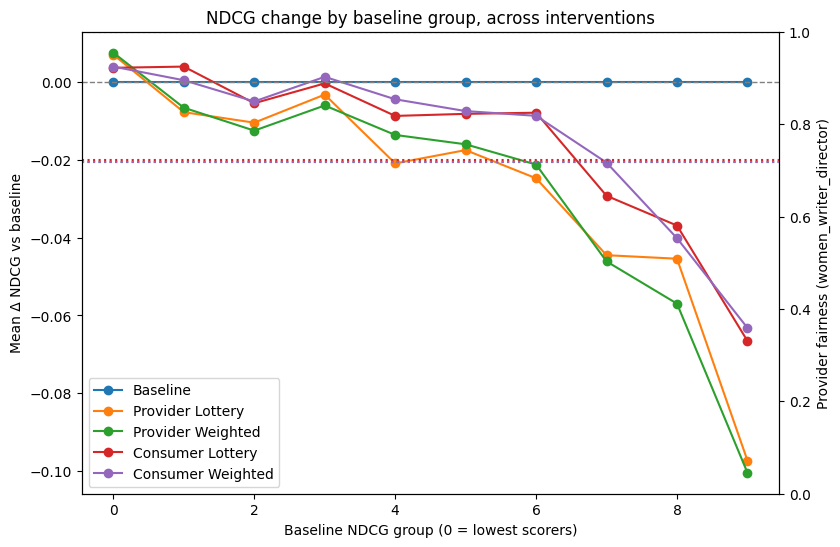

In [11]:
files = {
    "Baseline": "data/movies/movie_fold1_BPR_baseline.json",
    "Provider Lottery": "data/movies/ml-1m_fold1_BPR_group_weighted_scoring_product_lottery_0.1_fold1.json",
    "Provider Weighted": "data/movies/ml-1m_fold1_BPR_group_weighted_scoring_weighted_product_allocation_0.1_fold1.json",
    "Consumer Lottery": "data/movies/ml-1m_fold1_BPR_ind_weighted_scoring_product_lottery_0.1_fold1.json",
    "Consumer Weighted": "data/movies/ml-1m_fold1_BPR_ind_weighted_scoring_weighted_product_allocation_0.1_fold1.json",
}

analyze_fairness(files, groups=20, provider="women_writer_director")